<a href="https://colab.research.google.com/github/aniilkeles/Machine-Learning-Projects/blob/main/Projects/CarPricePredictionMLProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📌 Project Overview – Used Car Price Prediction

This project focuses on building a machine learning system to predict the market price of used cars based on their technical specifications and characteristics. The primary objective is to analyze the factors affecting vehicle prices and develop a robust regression model capable of generating accurate price estimates.

The dataset contains various features describing each vehicle, including:

Brand / Model – The manufacturer and model of the car

Year – Production year of the vehicle

Mileage (KM Driven) – Total distance driven

Fuel Type – Petrol, Diesel, Hybrid, etc.

Transmission – Manual or Automatic

Engine Size / Power – Technical performance indicator

Location / Seller Type – Geographic or ownership information

Price (Target Variable) – Market selling price of the vehicle

Through Exploratory Data Analysis (EDA), the project investigates price distribution, outliers, skewness, feature relationships, and potential multicollinearity issues. Feature engineering techniques such as vehicle age calculation, mileage per year, categorical encoding, and target transformation (e.g., log transformation) are applied to enhance model performance.

Multiple regression algorithms will be implemented and compared, including:

Linear Regression

Ridge / Lasso Regression

Random Forest Regressor

Gradient Boosting / XGBoost

The best-performing model will be selected based on evaluation metrics such as R², RMSE, and cross-validation performance.

Finally, the selected model will be exported and deployed as a production-ready prediction system. The model will be integrated into an external application (e.g., API or web interface), allowing users to input vehicle attributes and receive real-time price predictions. This transforms the machine learning solution into a usable product, such as a used-car valuation tool or pricing recommendation engine.

In [67]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/used_cars.csv')

In [70]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [72]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [73]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [74]:
df[df.duplicated()]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price


In [75]:
vehicle_cols = ["brand", "model", "model_year", "milage", "engine", "transmission"]

df.duplicated(subset=vehicle_cols).sum()

np.int64(2)

In [76]:
duplicates = df[df.duplicated(subset=vehicle_cols, keep=False)]
duplicates

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
122,Rivian,R1S Adventure Package,2023,"2,500 mi.",NaN,835.0HP Electric Motor Electric Fuel System,A/T,Green,White,None reported,Yes,"$94,000"
472,Rivian,R1S Adventure Package,2023,"2,500 mi.",NaN,835.0HP Electric Motor Electric Fuel System,A/T,Gray,Gray,None reported,Yes,"$91,000"
827,Ford,F-250 Lariat,2019,"85,000 mi.",Diesel,450.0HP 6.7L 8 Cylinder Engine Diesel Fuel,6-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,"$55,000"
1940,Ford,F-250 Lariat,2019,"85,000 mi.",Diesel,450.0HP 6.7L 8 Cylinder Engine Diesel Fuel,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$52,500"


In [77]:
df.duplicated(subset=df.columns).sum()

np.int64(0)

In [78]:
df['price'].unique()

array(['$10,300', '$38,005', '$54,598', ..., '$59,335', '$349,950',
       '$90,998'], dtype=object)

In [79]:
df['price'] = df['price'].str.replace('$','',regex=False)

In [80]:
df['price'].unique()

array(['10,300', '38,005', '54,598', ..., '59,335', '349,950', '90,998'],
      dtype=object)

In [81]:
df['price'] = df['price'].str.replace(',','',regex=False).astype(float)

In [82]:
df['price'].unique()

array([ 10300.,  38005.,  54598., ...,  59335., 349950.,  90998.])

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   object 
 4   fuel_type     3839 non-null   object 
 5   engine        4009 non-null   object 
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      3896 non-null   object 
 10  clean_title   3413 non-null   object 
 11  price         4009 non-null   float64
dtypes: float64(1), int64(1), object(10)
memory usage: 376.0+ KB


In [84]:
df['milage'].unique()

array(['51,000 mi.', '34,742 mi.', '22,372 mi.', ..., '53,705 mi.',
       '714 mi.', '2,116 mi.'], dtype=object)

In [85]:
df["milage"] = (df["milage"].str.replace(" mi.","",regex=False).str.replace(",","",regex=False)).astype(float)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     3839 non-null   object 
 5   engine        4009 non-null   object 
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      3896 non-null   object 
 10  clean_title   3413 non-null   object 
 11  price         4009 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 376.0+ KB


In [87]:
#from datetime import datetime
#current_year = datetime.now().year
#df["car_age"] = current_year - df["model_year"]
df['engine'].unique()

array(['300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability',
       '3.8L V6 24V GDI DOHC', '3.5 Liter DOHC', ...,
       '136.0HP 1.8L 4 Cylinder Engine Gasoline Fuel',
       '270.0HP 2.0L 4 Cylinder Engine Gasoline Fuel',
       '420.0HP 5.9L 12 Cylinder Engine Gasoline Fuel'], dtype=object)

In [88]:
df["engine"] = (
    df["engine"]
    .str.extract(r"(\d+\.?\d*)HP", expand=False)
    .astype(float)
)

In [89]:
df['engine'].unique()

array([ 300.,   nan,  354.,  292.,  282.,  311.,  534.,  715.,  382.,
        400.,  375.,  305.,  287.,  550.,  120.,  355.,  276.,  445.,
        362.,  345.,  383.,  180.,  211.,  173.,  240.,  552.,  536.,
        310.,  228.,  268.,  503.,  325.,  208.,  250.,  200.,  420.,
        302.,  306.,  237.,  248.,  425.,  582.,  444.,  335.,  424.,
        340.,  225.,  365.,  315.,  199.,  560.,  326.,  165.,  835.,
        241.,  215.,  130.,  288.,  369.,  195.,  285.,  485.,  132.,
        416.,  360.,  280.,  620.,  265.,  469.,  169.,  330.,  275.,
        303.,  450.,  651.,  255.,  455.,  182.,  236.,  370.,  212.,
        565.,  230.,  171.,  252.,  220.,  188.,  235.,  320.,  138.,
        291.,  523.,  440.,  181.,  429.,  263.,  210.,  404.,  670.,
        563.,  283.,  150.,  266.,  328.,  304.,  381.,  493.,  641.,
        760.,  329.,  239.,  160.,  402.,  166.,  390.,  147.,  357.,
        271.,  350.,  611.,  295.,  603.,  454.,  490.,  301.,  395.,
        272.,  437.,

In [90]:
df['engine'].isnull().sum()

np.int64(808)

In [91]:
df[df["engine"].isnull()]


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,NaN,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,NaN,Automatic,Blue,Black,None reported,NaN,54598.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,NaN,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0
5,Acura,ILX 2.4L,2016,136397.0,Gasoline,NaN,F,Silver,Ebony.,None reported,NaN,14798.0
10,Land,Rover Range Rover Sport 3.0 Supercharged HST,2021,27608.0,Gasoline,NaN,Automatic,Fuji White,Pimento / Ebony,None reported,NaN,73897.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3971,Buick,Envision Essence,2021,36544.0,Gasoline,NaN,9-Speed Automatic,Dark Moon Blue Metallic,Ebony,None reported,Yes,33290.0
3984,Toyota,Land Cruiser Base,1994,178416.0,–,NaN,A/T,Green,Beige,None reported,Yes,9000.0
3991,Porsche,Cayenne Turbo,2020,39611.0,Gasoline,NaN,8-Speed Automatic,Quartzite Grey Metallic,Black,None reported,NaN,89900.0
4004,Bentley,Continental GT Speed,2023,714.0,Gasoline,NaN,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,349950.0


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     3839 non-null   object 
 5   engine        3201 non-null   float64
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      3896 non-null   object 
 10  clean_title   3413 non-null   object 
 11  price         4009 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 376.0+ KB


In [93]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,NaN,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,NaN,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,NaN,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0


In [94]:
from datetime import datetime
current_year = datetime.now().year
df["car_age"] = current_year - df["model_year"]

In [95]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,NaN,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,NaN,Automatic,Blue,Black,None reported,NaN,54598.0,4
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,NaN,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,5


In [96]:
df.drop("model_year",axis=1,inplace=True)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   milage        4009 non-null   float64
 3   fuel_type     3839 non-null   object 
 4   engine        3201 non-null   float64
 5   transmission  4009 non-null   object 
 6   ext_col       4009 non-null   object 
 7   int_col       4009 non-null   object 
 8   accident      3896 non-null   object 
 9   clean_title   3413 non-null   object 
 10  price         4009 non-null   float64
 11  car_age       4009 non-null   int64  
dtypes: float64(3), int64(1), object(8)
memory usage: 376.0+ KB


In [98]:
df["accident"].isnull().sum()

np.int64(113)

In [99]:
df["has_accident"] = df["accident"].map(
    {
         "None reported" : 0,
         "At least 1 accident or damage reported" : 1
    }
                                        )
df.drop("accident",axis=1,inplace=True)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   milage        4009 non-null   float64
 3   fuel_type     3839 non-null   object 
 4   engine        3201 non-null   float64
 5   transmission  4009 non-null   object 
 6   ext_col       4009 non-null   object 
 7   int_col       4009 non-null   object 
 8   clean_title   3413 non-null   object 
 9   price         4009 non-null   float64
 10  car_age       4009 non-null   int64  
 11  has_accident  3896 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 376.0+ KB


In [101]:
df.head()

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,car_age,has_accident
0,Ford,Utility Police Interceptor Base,51000.0,E85 Flex Fuel,300.0,6-Speed A/T,Black,Black,Yes,10300.0,13,1.0
1,Hyundai,Palisade SEL,34742.0,Gasoline,NaN,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,5,1.0
2,Lexus,RX 350 RX 350,22372.0,Gasoline,NaN,Automatic,Blue,Black,NaN,54598.0,4,0.0
3,INFINITI,Q50 Hybrid Sport,88900.0,Hybrid,354.0,7-Speed A/T,Black,Black,Yes,15500.0,11,0.0
4,Audi,Q3 45 S line Premium Plus,9835.0,Gasoline,NaN,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,5,0.0


In [102]:
df['clean_title'].isnull().sum()

np.int64(596)

In [103]:
df["clean_title"].value_counts(dropna=False)

,count
clean_title,
Yes,3413
NaN,596


In [104]:
df.groupby("clean_title")["price"].mean()

,price
clean_title,
Yes,41734.390272


In [105]:
df.groupby("clean_title", dropna=False)["price"].mean()


,price
clean_title,
Yes,41734.390272
NaN,60695.077181


In [106]:
df["clean_title"] = df["clean_title"].map({"Yes": 1})
df["clean_title"] = df["clean_title"].fillna(-1)

In [107]:
df['clean_title'].unique()

array([ 1., -1.])

In [108]:
df["transmission"].unique()

array(['6-Speed A/T', '8-Speed Automatic', 'Automatic', '7-Speed A/T',
       'F', 'A/T', '8-Speed A/T', 'Transmission w/Dual Shift Mode',
       '9-Speed Automatic', '6-Speed M/T', '10-Speed A/T', '9-Speed A/T',
       '5-Speed A/T', '1-Speed A/T', 'Automatic CVT',
       '7-Speed Automatic with Auto-Shift', 'CVT-F', 'M/T',
       '6-Speed Automatic with Auto-Shift', '10-Speed Automatic',
       'CVT Transmission', '4-Speed A/T', '6-Speed Automatic',
       '4-Speed Automatic', '7-Speed M/T',
       '8-Speed Automatic with Auto-Shift', '5-Speed Automatic',
       '8-SPEED AT', '1-Speed Automatic', '5-Speed M/T', 'Manual',
       '6-Speed Manual', 'Variable', '2', '7-Speed Manual',
       'Automatic, 9-Spd 9G-Tronic', 'Automatic, 8-Spd',
       'Automatic, 8-Spd Sport w/Sport & Manual Modes', '–',
       'Auto, 6-Spd w/CmdShft', 'Transmission Overdrive Switch',
       '7-Speed Automatic', 'Automatic, 8-Spd PDK Dual-Clutch',
       'Automatic, 8-Spd M STEPTRONIC w/Drivelogic, Sport & Ma

In [109]:
df["transmission"].value_counts()

,count
transmission,
A/T,1037
8-Speed A/T,406
Transmission w/Dual Shift Mode,398
6-Speed A/T,362
6-Speed M/T,248
...,...
10-Speed Automatic with Overdrive,1
9-Speed Automatic with Auto-Shift,1
SCHEDULED FOR OR IN PRODUCTION,1


In [110]:
df["transmission"] = df["transmission"].str.lower().str.strip()

In [111]:
def simplify_transmission(x):
    if pd.isna(x):
        return "other"

    if "manual" in x or "m/t" in x or "mt" in x:
        return "manual"

    if "automatic" in x or "a/t" in x or "cvt" in x or "dual" in x or "tronic" in x:
        return "automatic"

    return "other"

In [112]:
df["transmission_type"] = df["transmission"].apply(simplify_transmission)

In [113]:
df["transmission_type"].value_counts()

,count
transmission_type,
automatic,3607
manual,376
other,26


In [114]:
df.drop("transmission",axis=1,inplace=True)

In [115]:
df.head()

,brand,model,milage,fuel_type,engine,ext_col,int_col,clean_title,price,car_age,has_accident,transmission_type
0,Ford,Utility Police Interceptor Base,51000.0,E85 Flex Fuel,300.0,Black,Black,1.0,10300.0,13,1.0,automatic
1,Hyundai,Palisade SEL,34742.0,Gasoline,NaN,Moonlight Cloud,Gray,1.0,38005.0,5,1.0,automatic
2,Lexus,RX 350 RX 350,22372.0,Gasoline,NaN,Blue,Black,-1.0,54598.0,4,0.0,automatic
3,INFINITI,Q50 Hybrid Sport,88900.0,Hybrid,354.0,Black,Black,1.0,15500.0,11,0.0,automatic
4,Audi,Q3 45 S line Premium Plus,9835.0,Gasoline,NaN,Glacier White Metallic,Black,-1.0,34999.0,5,0.0,automatic


In [116]:
df["fuel_type"].value_counts(dropna=False)

,count
fuel_type,
Gasoline,3309
Hybrid,194
NaN,170
E85 Flex Fuel,139
Diesel,116
–,45
Plug-In Hybrid,34
not supported,2


In [117]:
df["fuel_type"].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', nan, 'Diesel',
       'Plug-In Hybrid', '–', 'not supported'], dtype=object)

In [118]:
df["fuel_type"] = df["fuel_type"].replace(["–", "not supported"], None)

df["fuel_missing"] = df["fuel_type"].isnull().astype(int)

df["is_diesel"] = df["fuel_type"].str.contains("diesel", case=False, na=False).astype(int)
df["is_hybrid"] = df["fuel_type"].str.contains("hybrid", case=False, na=False).astype(int)
df["is_flexfuel"] = df["fuel_type"].str.contains("flex", case=False, na=False).astype(int)

df.drop("fuel_type", axis=1, inplace=True)

In [119]:
df.head()

,brand,model,milage,engine,ext_col,int_col,clean_title,price,car_age,has_accident,transmission_type,fuel_missing,is_diesel,is_hybrid,is_flexfuel
0,Ford,Utility Police Interceptor Base,51000.0,300.0,Black,Black,1.0,10300.0,13,1.0,automatic,0,0,0,1
1,Hyundai,Palisade SEL,34742.0,NaN,Moonlight Cloud,Gray,1.0,38005.0,5,1.0,automatic,0,0,0,0
2,Lexus,RX 350 RX 350,22372.0,NaN,Blue,Black,-1.0,54598.0,4,0.0,automatic,0,0,0,0
3,INFINITI,Q50 Hybrid Sport,88900.0,354.0,Black,Black,1.0,15500.0,11,0.0,automatic,0,0,1,0
4,Audi,Q3 45 S line Premium Plus,9835.0,NaN,Glacier White Metallic,Black,-1.0,34999.0,5,0.0,automatic,0,0,0,0


In [120]:
df[["fuel_missing","is_diesel","is_hybrid","is_flexfuel"]].sum()

,0
fuel_missing,217
is_diesel,116
is_hybrid,228
is_flexfuel,139


In [125]:
df["model"].unique()

array(['Utility Police Interceptor Base', 'Palisade SEL', 'RX 350 RX 350',
       ..., 'Martin DB7 Vantage Volante', 'Impala 2LZ', 'Taycan'],
      dtype=object)

In [128]:
df.drop("model",axis=1,inplace=True) # I will apply this scenario to model column and I'll compare success of my model top_models = df["model"].value_counts().nlargest(30).index
#df["model_simplified"] = df["model"].apply(lambda x: x if x in top_models else "other")


KeyError: "['model'] not found in axis"

In [127]:
df.head()

,brand,milage,engine,ext_col,int_col,clean_title,price,car_age,has_accident,transmission_type,fuel_missing,is_diesel,is_hybrid,is_flexfuel
0,Ford,51000.0,300.0,Black,Black,1.0,10300.0,13,1.0,automatic,0,0,0,1
1,Hyundai,34742.0,NaN,Moonlight Cloud,Gray,1.0,38005.0,5,1.0,automatic,0,0,0,0
2,Lexus,22372.0,NaN,Blue,Black,-1.0,54598.0,4,0.0,automatic,0,0,0,0
3,INFINITI,88900.0,354.0,Black,Black,1.0,15500.0,11,0.0,automatic,0,0,1,0
4,Audi,9835.0,NaN,Glacier White Metallic,Black,-1.0,34999.0,5,0.0,automatic,0,0,0,0


In [132]:
df['ext_col'].value_counts()

,count
ext_col,
Black,905
White,816
Gray,496
Silver,374
Blue,349
...,...
Pristine White,1
Garnet Red Metallic,1
Cayenne Red Tintcoat,1


In [131]:
df['int_col'].value_counts()

,count
int_col,
Black,2025
Beige,538
Gray,472
Brown,157
–,133
...,...
Gray w/Blue Bolsters,1
Very Light Cashmere,1
Black / Gray,1


In [133]:
def simplify_color(x):
    if pd.isna(x) or x == "–":
        return "unknown"

    x = x.lower().strip()

    if "black" in x:
        return "black"
    elif "white" in x:
        return "white"
    elif "gray" in x or "grey" in x or "graphite" in x:
        return "gray"
    elif "silver" in x:
        return "silver"
    elif "blue" in x:
        return "blue"
    elif "red" in x:
        return "red"
    elif "brown" in x:
        return "brown"
    elif "beige" in x:
        return "beige"
    elif "green" in x:
        return "green"
    else:
        return "other"

df["ext_color_simple"] = df["ext_col"].apply(simplify_color)
df["int_color_simple"] = df["int_col"].apply(simplify_color)

df.drop(["ext_col", "int_col"], axis=1, inplace=True)


In [134]:
df["int_color_simple"].value_counts()

,count
int_color_simple,
black,2155
beige,551
gray,493
other,193
brown,163
red,134
unknown,133
white,131
blue,32


In [135]:
df["ext_color_simple"].value_counts()

,count
ext_color_simple,
black,1016
white,922
gray,547
silver,421
blue,395
red,311
other,219
green,80
brown,44


In [136]:
df.head()

,brand,milage,engine,clean_title,price,car_age,has_accident,transmission_type,fuel_missing,is_diesel,is_hybrid,is_flexfuel,ext_color_simple,int_color_simple
0,Ford,51000.0,300.0,1.0,10300.0,13,1.0,automatic,0,0,0,1,black,black
1,Hyundai,34742.0,NaN,1.0,38005.0,5,1.0,automatic,0,0,0,0,other,gray
2,Lexus,22372.0,NaN,-1.0,54598.0,4,0.0,automatic,0,0,0,0,blue,black
3,INFINITI,88900.0,354.0,1.0,15500.0,11,0.0,automatic,0,0,1,0,black,black
4,Audi,9835.0,NaN,-1.0,34999.0,5,0.0,automatic,0,0,0,0,white,black


In [145]:
#EDA

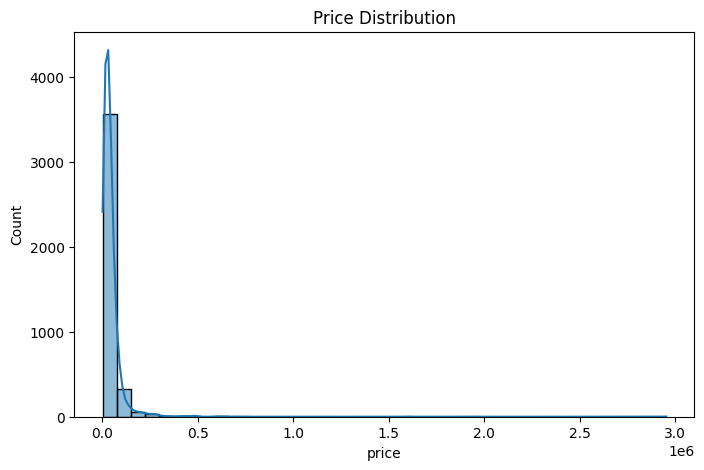

In [137]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Price Distribution")
plt.show()

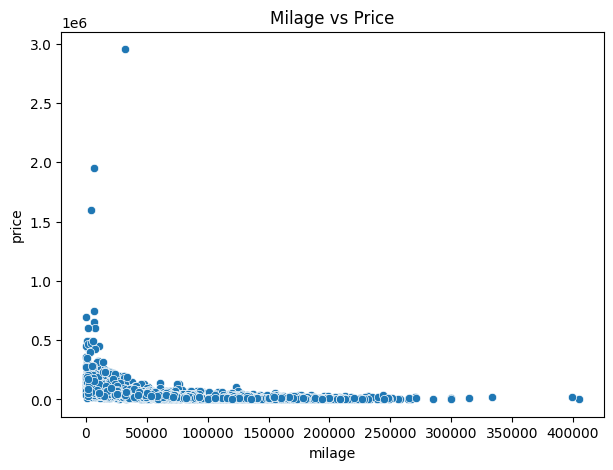

In [138]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="milage", y="price", data=df)
plt.title("Milage vs Price")
plt.show()

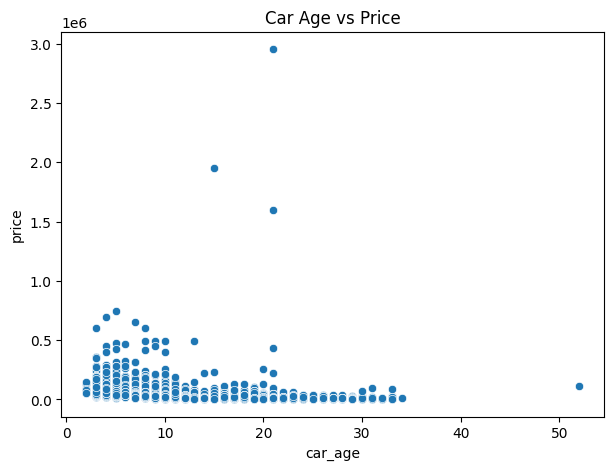

In [139]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="car_age", y="price", data=df)
plt.title("Car Age vs Price")
plt.show()

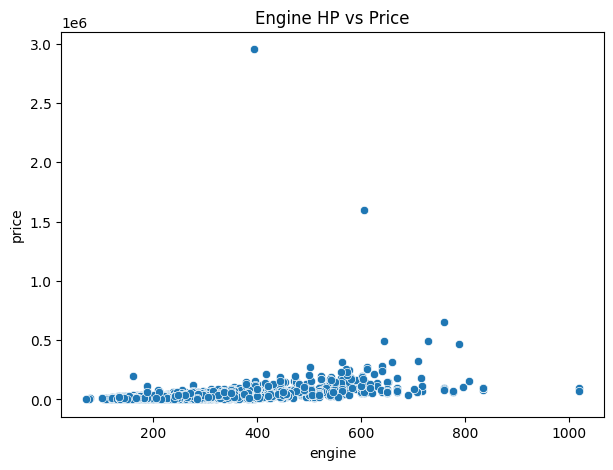

In [140]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="engine", y="price", data=df)
plt.title("Engine HP vs Price")
plt.show()

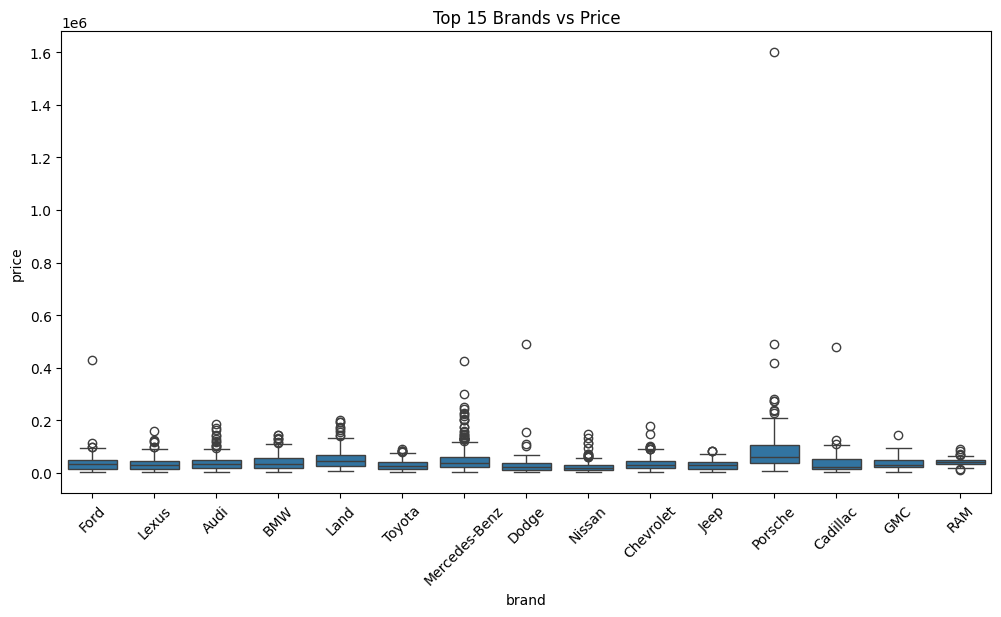

In [141]:
top_brands = df["brand"].value_counts().nlargest(15).index

plt.figure(figsize=(12,6))
sns.boxplot(x="brand", y="price", data=df[df["brand"].isin(top_brands)])
plt.xticks(rotation=45)
plt.title("Top 15 Brands vs Price")
plt.show()

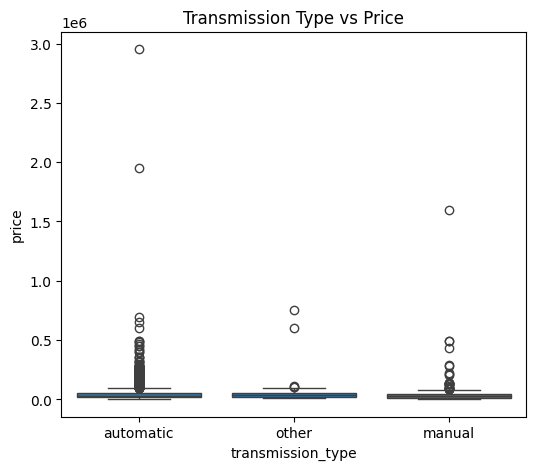

In [142]:
plt.figure(figsize=(6,5))
sns.boxplot(x="transmission_type", y="price", data=df)
plt.title("Transmission Type vs Price")
plt.show()

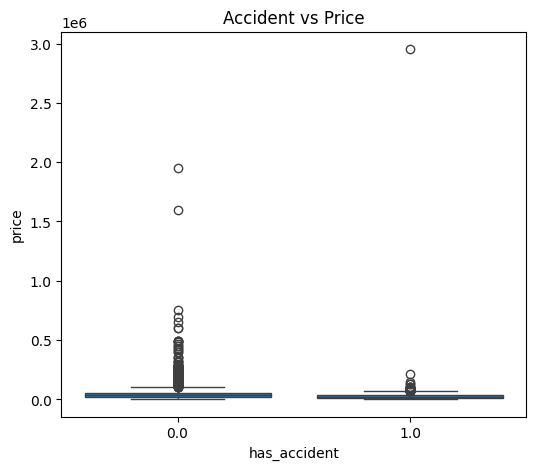

In [143]:
plt.figure(figsize=(6,5))
sns.boxplot(x="has_accident", y="price", data=df)
plt.title("Accident vs Price")
plt.show()

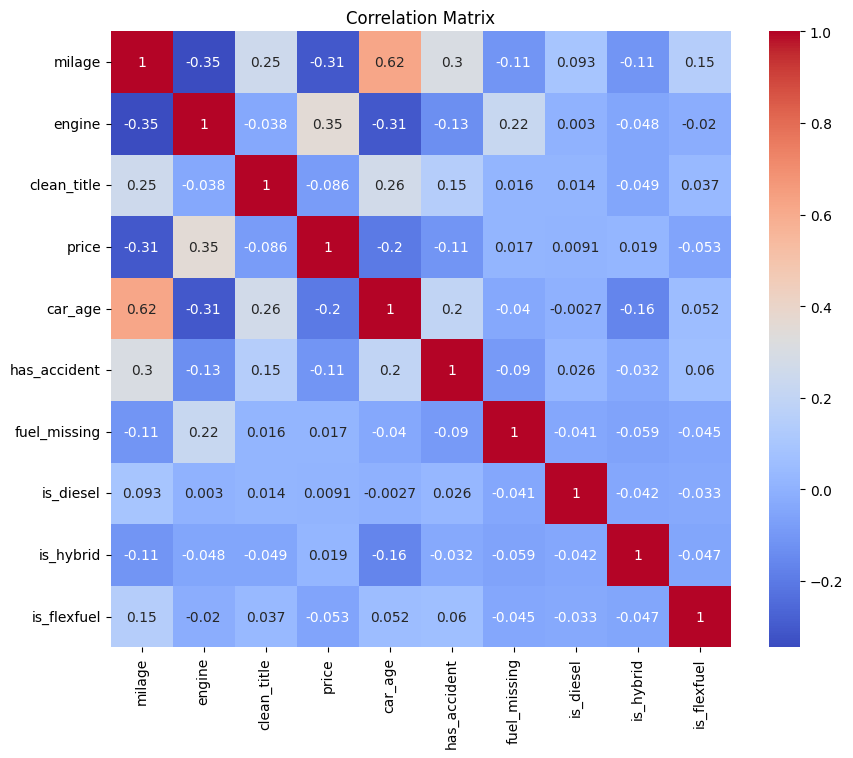

In [144]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

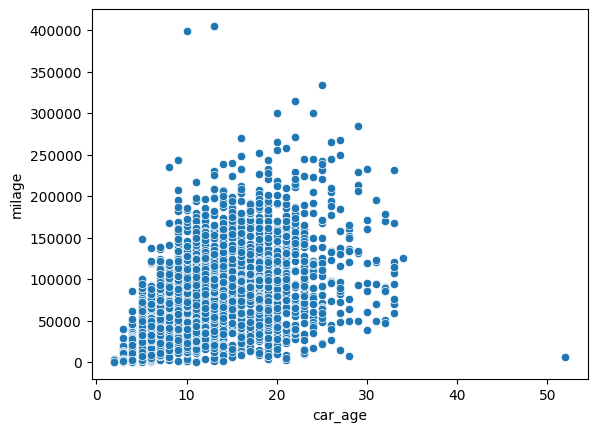

In [155]:
sns.scatterplot(data=df,x="car_age",y="milage")
plt.show()

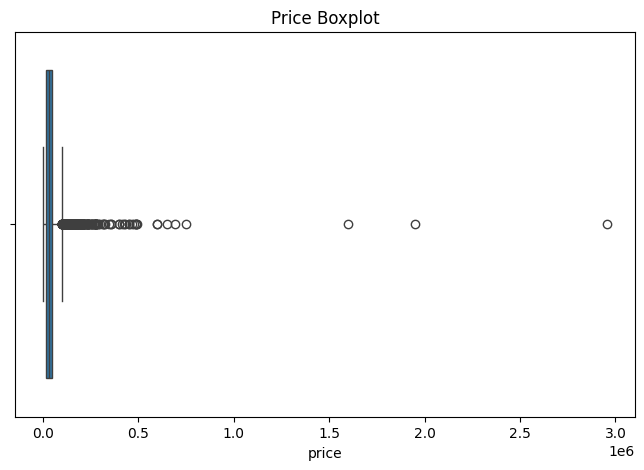

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Price Boxplot")
plt.show()

In [147]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

print("Outlier count:", outliers.shape[0])
print("Upper bound:", upper_bound)

Outlier count: 244
Upper bound: 99175.0


In [149]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['milage', 'engine', 'clean_title', 'price', 'car_age', 'has_accident',
       'fuel_missing', 'is_diesel', 'is_hybrid', 'is_flexfuel'],
      dtype='object')

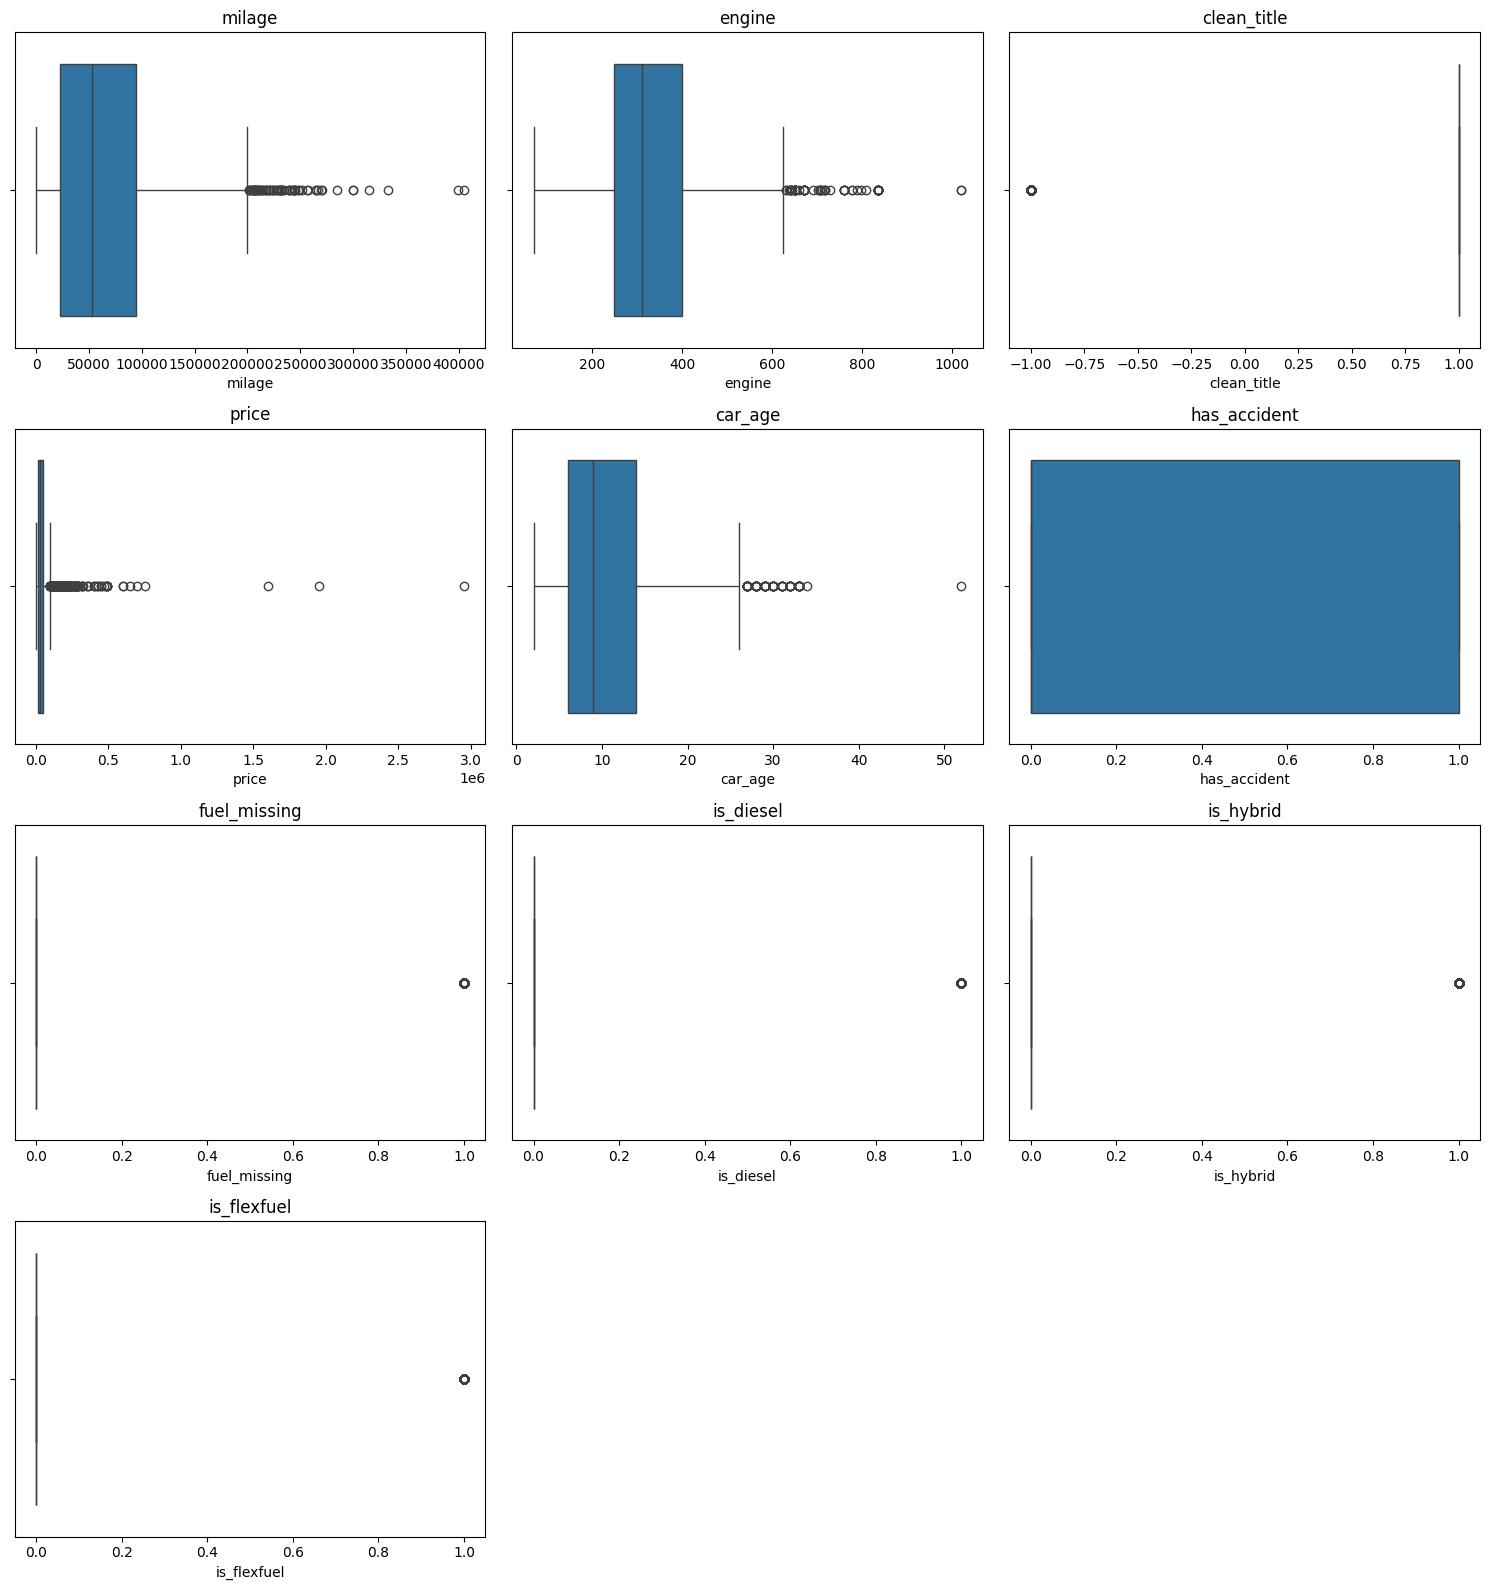

In [152]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [151]:
def check_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

        print(f"{col} -> Outlier count: {count}")

check_outliers(df, numeric_cols)

milage -> Outlier count: 69
engine -> Outlier count: 63
clean_title -> Outlier count: 596
price -> Outlier count: 244
car_age -> Outlier count: 67
has_accident -> Outlier count: 0
fuel_missing -> Outlier count: 217
is_diesel -> Outlier count: 116
is_hybrid -> Outlier count: 228
is_flexfuel -> Outlier count: 139


In [156]:
# train-test-split

In [157]:
X = df.drop("price",axis=1)
y = df["price"]

In [158]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [159]:
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [160]:
numeric_cols = ["milage", "engine", "car_age"]

In [161]:
clip_values = {}

for col in numeric_cols:
    upper = X_train[col].quantile(0.99)
    clip_values[col] = upper

    X_train[col] = np.clip(X_train[col], None, upper)
    X_test[col] = np.clip(X_test[col], None, upper)

In [167]:
X_test['car_age'].isnull().sum()

np.int64(0)

In [168]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

num_cols_full = ["milage", "engine", "car_age"]

num_imputer.fit(X_train[num_cols_full])

X_train[num_cols_full] = num_imputer.transform(X_train[num_cols_full])
X_test[num_cols_full] = num_imputer.transform(X_test[num_cols_full])


In [169]:
bin_cols = ["clean_title", "has_accident"]

bin_imputer = SimpleImputer(strategy="most_frequent")

bin_imputer.fit(X_train[bin_cols])

X_train[bin_cols] = bin_imputer.transform(X_train[bin_cols])
X_test[bin_cols] = bin_imputer.transform(X_test[bin_cols])

In [171]:
X_test.isnull().sum()

,0
brand,0
milage,0
engine,0
clean_title,0
car_age,0
has_accident,0
transmission_type,0
fuel_missing,0
is_diesel,0
is_hybrid,0


In [172]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = ["milage", "engine", "car_age"]

binary_cols = [
    "clean_title",
    "has_accident",
    "fuel_missing",
    "is_diesel",
    "is_hybrid",
    "is_flexfuel"
]

categorical_cols = [
    "brand",
    "transmission_type",
    "ext_color_simple",
    "int_color_simple"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("bin", "passthrough", binary_cols)
])


In [173]:
# model

In [175]:
from sklearn.linear_model import LinearRegression

In [176]:
model = Pipeline(
    [
        ("preprocessing",preprocessor),
        ("regressor",LinearRegression())
    ]
)

In [177]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['milage', 'engine',
                                                   'car_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'transmission_type',
                                                   'ext_color_simple',
                                                   'int_color_simple']),
                                                 ('bin', 'passthrough',
                                                  ['clean_title',
                                                   'has_accident',
                                                   'fuel_missing', 'is_diesel',
                                                   'is_hybrid',
                                                   'is_flexfuel'])])),
                ('regressor', LinearRegression())])

In [178]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [179]:
y_pred_log = model.predict(X_test)

In [180]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [181]:
print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.3397688731679418
MAE: 12868.082716009252
RMSE: 55788.16145932033


In [182]:
from sklearn.model_selection import GridSearchCV

In [183]:
param_grid = {
    "regressor__fit_intercept": [True, False],
    "regressor__positive": [True, False]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best Params: {'regressor__fit_intercept': True, 'regressor__positive': False}
Best CV R2: 0.7914556751483998


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **la

In [184]:
from sklearn.linear_model import Ridge

In [187]:
ridge_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", Ridge())
])

In [188]:
ridge_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['milage', 'engine',
                                                   'car_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'transmission_type',
                                                   'ext_color_simple',
                                                   'int_color_simple']),
                                                 ('bin', 'passthrough',
                                                  ['clean_title',
                                                   'has_accident',
                                                   'fuel_missing', 'is_diesel',
                                                   'is_hybrid',
                                                   'is_flexfuel'])])),
                ('regressor', Ridge())])

In [189]:
y_pred_log = ridge_model.predict(X_test)

In [190]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [191]:
print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.33247120184521495
MAE: 12737.17401536595
RMSE: 56095.633205824066


In [192]:
ridge_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", Ridge())
])

param_grid = {
    "regressor__alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]
}

grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best Alpha: {'regressor__alpha': 1}
Best CV R2: 0.7925998355420465


In [193]:
best_ridge = grid.best_estimator_

y_pred_log = best_ridge.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("Test R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Test R2: 0.33247120184521495
MAE: 12737.17401536595
RMSE: 56095.633205824066


In [194]:
print("Test R2 (log space):", r2_score(y_test, y_pred_log))

Test R2 (log space): 0.8157738478119101


In [195]:
from sklearn.neighbors import KNeighborsRegressor

In [196]:
knn_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", KNeighborsRegressor())
])

In [197]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['milage', 'engine',
                                                   'car_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'transmission_type',
                                                   'ext_color_simple',
                                                   'int_color_simple']),
                                                 ('bin', 'passthrough',
                                                  ['clean_title',
                                                   'has_accident',
                                                   'fuel_missing', 'is_diesel',
                                                   'is_hybrid',
                                                   'is_flexfuel'])])),
                ('regressor', KNeighborsRegressor())])

In [198]:
y_pred_log = knn_model.predict(X_test)

In [199]:
print("Test R2 (log space):", r2_score(y_test, y_pred_log))

Test R2 (log space): 0.7736749944072261


In [200]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("Test R2 (original):", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Test R2 (original): 0.25388355221650993
MAE: 14644.880882666439
RMSE: 59305.82590789305


In [201]:
from sklearn.tree import DecisionTreeRegressor

In [202]:
dt_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=15))
])

In [203]:
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['milage', 'engine',
                                                   'car_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'transmission_type',
                                                   'ext_color_simple',
                                                   'int_color_simple']),
                                                 ('bin', 'passthrough',
                                                  ['clean_title',
                                                   'has_accident',
                                                   'fuel_missing', 'is_diesel',
                                                   'is_hybrid',
                                                   'is_flexfuel'])])),
                ('regressor', DecisionTreeRegressor(random_state=15))])

In [204]:
y_pred_log = dt_model.predict(X_test)

In [205]:
print("Decision Tree R2 (log space):", r2_score(y_test, y_pred_log))

Decision Tree R2 (log space): 0.6735743969418537


In [206]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("Decision Tree R2 (original):", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Decision Tree R2 (original): 0.21968782478856763
MAE: 16104.769690927214
RMSE: 60649.64219272595


In [207]:
y_train_pred_log = dt_model.predict(X_train)
print("Train R2 (log space):", r2_score(y_train, y_train_pred_log))

Train R2 (log space): 1.0


In [208]:
from sklearn.ensemble import RandomForestRegressor

In [209]:
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(
        random_state=15,
        n_jobs=-1
    ))
])

In [210]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['milage', 'engine',
                                                   'car_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'transmission_type',
                                                   'ext_color_simple',
                                                   'int_color_simple']),
                                                 ('bin', 'passthrough',
                                                  ['clean_title',
                                                   'has_accident',
                                                   'fuel_missing', 'is_diesel',
                                                   'is_hybrid',
                                                   'is_flexfuel'])])),
                ('regressor',
                 RandomForestRegressor(n_jobs=-1, random_state=15))])

In [212]:
y_pred_log = rf_model.predict(X_test)

print("RF R2 (log space):", r2_score(y_test, y_pred_log))

RF R2 (log space): 0.8336827746734191


In [213]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("RF R2 (original):", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

RF R2 (original): 0.43775628863537974
MAE: 11550.789804240248
RMSE: 51482.111958022346


In [214]:
param_dist = {
    "regressor__n_estimators": [100, 200, 300, 500],
    "regressor__max_depth": [None, 10, 20, 30, 50],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", "log2", None]
}

In [215]:
from sklearn.model_selection import RandomizedSearchCV

In [216]:
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(
        random_state=15,
        n_jobs=-1
    ))
])

In [217]:
random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    verbose=2,
    random_state=15,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['milage',
                                                                                'engine',
                                                                                'car_age']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['brand',
                                                                                'transmission_type',
                                                                                'ext_color_simple',
                                                                                'int_color_simple']),
                                                                              ('bin',
                                                                               'passthrough',
                                                                               ['clean_title',
                                                                                'has_accident',
                                                                                'fuel_missing',
                                                                                'is_diesel',
                                                                                'is...
                                             ('regressor',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=15))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'regressor__max_depth': [None, 10, 20,
                                                                 30, 50],
                                        'regressor__max_features': ['sqrt',
                                                                    'log2',
                                                                    None],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        4],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [100, 200,
                                                                    300, 500]},
                   random_state=15, scoring='r2', verbose=2)

In [218]:
print("Best Params:", random_search.best_params_)
print("Best CV R2:", random_search.best_score_)

Best Params: {'regressor__n_estimators': 200, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': None, 'regressor__max_depth': None}
Best CV R2: 0.8123404454922456


In [219]:
best_rf = random_search.best_estimator_

y_pred_log = best_rf.predict(X_test)


y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("Test R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))


Test R2: 0.4291030087626876
MAE: 11511.1508361304
RMSE: 51876.77008455192


In [220]:
df = df[df["price"] < 300000]

In [221]:
X = df.drop("price", axis=1)
y = df["price"]

In [222]:
y = np.log1p(y)

In [223]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=15
)


In [226]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["milage", "engine", "car_age"]
categorical_features = ["brand", "transmission_type",
                        "ext_color_simple", "int_color_simple"]
binary_features = ["clean_title", "has_accident",
                   "fuel_missing", "is_diesel",
                   "is_hybrid", "is_flexfuel"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("bin", binary_transformer, binary_features)
])


In [227]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=15,
        n_jobs=-1
    ))
])


In [228]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['milage', 'engine',
                                                   'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['brand', 'transmission_type',
                                                   'ext_color_simple',
                                                   'int_color_simple']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['clean_title',
                                                   'has_accident',
                                                   'fuel_missing', 'is_diesel',
                                                   'is_hybrid',
                                                   'is_flexfuel'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=15))])

In [229]:
y_pred_log = rf_model.predict(X_test)

print("R2 (log space):", r2_score(y_test, y_pred_log))

R2 (log space): 0.8343419098021767


In [230]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.7444962991685362
MAE: 9506.794405986782
RMSE: 18047.3749850102


In [231]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", XGBRegressor(
        random_state=15,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_log = xgb_model.predict(X_test)

# Log space
print("XGB R2 (log space):", r2_score(y_test, y_pred_log))

# Original space
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("XGB R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

XGB R2 (log space): 0.8619293957870939
XGB R2: 0.8071517231133226
MAE: 8371.01941607199
RMSE: 15679.179280058139


In [233]:
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        random_state=15,
        n_jobs=-1
    ))
])

param_dist = {
    "regressor__n_estimators": [200, 300, 500, 700],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "regressor__max_depth": [3, 4, 5, 6, 8, 10],
    "regressor__subsample": [0.6, 0.7, 0.8, 1.0],
    "regressor__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "regressor__min_child_weight": [1, 3, 5, 7],
    "regressor__gamma": [0, 0.1, 0.3, 0.5]
}

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="r2",
    verbose=2,
    random_state=15,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['milage',
                                                                                'engine',
                                                                                'car_age']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'...
                   param_distributions={'regressor__colsample_bytree': [0.6,
                                                                        0.7,
                                                                        0.8,
                                                                        1.0],
                                        'regressor__gamma': [0, 0.1, 0.3, 0.5],
                                        'regressor__learning_rate': [0.01, 0.03,
                                                                     0.05, 0.1,
                                                                     0.2],
                                        'regressor__max_depth': [3, 4, 5, 6, 8,
                                                                 10],
                                        'regressor__min_child_weight': [1, 3, 5,
                                                                        7],
                                        'regressor__n_estimators': [200, 300,
                                                                    500, 700],
                                        'regressor__subsample': [0.6, 0.7, 0.8,
                                                                 1.0]},
                   random_state=15, scoring='r2', verbose=2)

In [234]:
print("Best Params:", random_search.best_params_)
print("Best CV R2:", random_search.best_score_)

Best Params: {'regressor__subsample': 1.0, 'regressor__n_estimators': 700, 'regressor__min_child_weight': 1, 'regressor__max_depth': 8, 'regressor__learning_rate': 0.03, 'regressor__gamma': 0, 'regressor__colsample_bytree': 0.7}
Best CV R2: 0.8560771079550189


In [235]:
best_xgb = random_search.best_estimator_

y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("Test R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Test R2: 0.8044157350109259
MAE: 8481.028590797032
RMSE: 15790.009843533337


In [236]:
from lightgbm import LGBMRegressor

lgbm_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LGBMRegressor(
        random_state=15,
        n_estimators=300,
        learning_rate=0.1
    ))
])

lgbm_model.fit(X_train, y_train)

y_pred_log = lgbm_model.predict(X_test)

print("LGBM R2 (log space):", r2_score(y_test, y_pred_log))

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("LGBM R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 650
[LightGBM] [Info] Number of data points in the train set: 3184, number of used features: 63
[LightGBM] [Info] Start training from score 10.283996
LGBM R2 (log space): 0.84478524156266
LGBM R2: 0.7270335112311055
MAE: 9515.97971728042
RMSE: 18653.920059346856


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [237]:
df["mileage_per_year"] = df["milage"] / (df["car_age"] + 1)
df["engine_per_year"] = df["engine"] / (df["car_age"] + 1)
df["engine_per_mileage"] = df["engine"] / (df["milage"] + 1)

In [238]:
X = df.drop("price", axis=1)
y = np.log1p(df["price"])

In [239]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=15
)

In [240]:
numeric_features = [
    "milage",
    "engine",
    "car_age",
    "mileage_per_year",
    "engine_per_year",
    "engine_per_mileage"
]

In [241]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", XGBRegressor(
        random_state=15,
        n_estimators=700,
        learning_rate=0.03,
        max_depth=8,
        subsample=1.0,
        colsample_bytree=0.7,
        objective="reg:squarederror",
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_log = xgb_model.predict(X_test)

print("XGB R2 (log space):", r2_score(y_test, y_pred_log))

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("XGB R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

XGB R2 (log space): 0.8621982839602392
XGB R2: 0.8044157350109259
MAE: 8481.028590797032
RMSE: 15790.009843533337
